# Heart Disease Prediction — ML Classification Project

**Goal:** Predict whether a patient has heart disease (`target = 1`) or not (`target = 0`)
based on 13 clinical features (age, cholesterol, chest pain type, max heart rate, etc.)

**Dataset:** UCI Heart Disease dataset (303 patients, 13 features + target)

**Pipeline:** Load Data → EDA → Preprocess → Train Models → Evaluate → Compare → Save Best Model


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)
import joblib

%matplotlib inline
sns.set_style("whitegrid")


## 2. Load Dataset

In [2]:
DATA_URL = "https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv"
df = pd.read_csv(DATA_URL)

print(f"Shape: {df.shape}")
df.head()


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
print("Missing values:", df.isnull().sum().sum())
df['target'].value_counts()


Missing values: 0


target
1    165
0    138
Name: count, dtype: int64

## 3. Exploratory Data Analysis (EDA)

Checking feature distributions, correlations, and how features relate to the target.


In [5]:
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


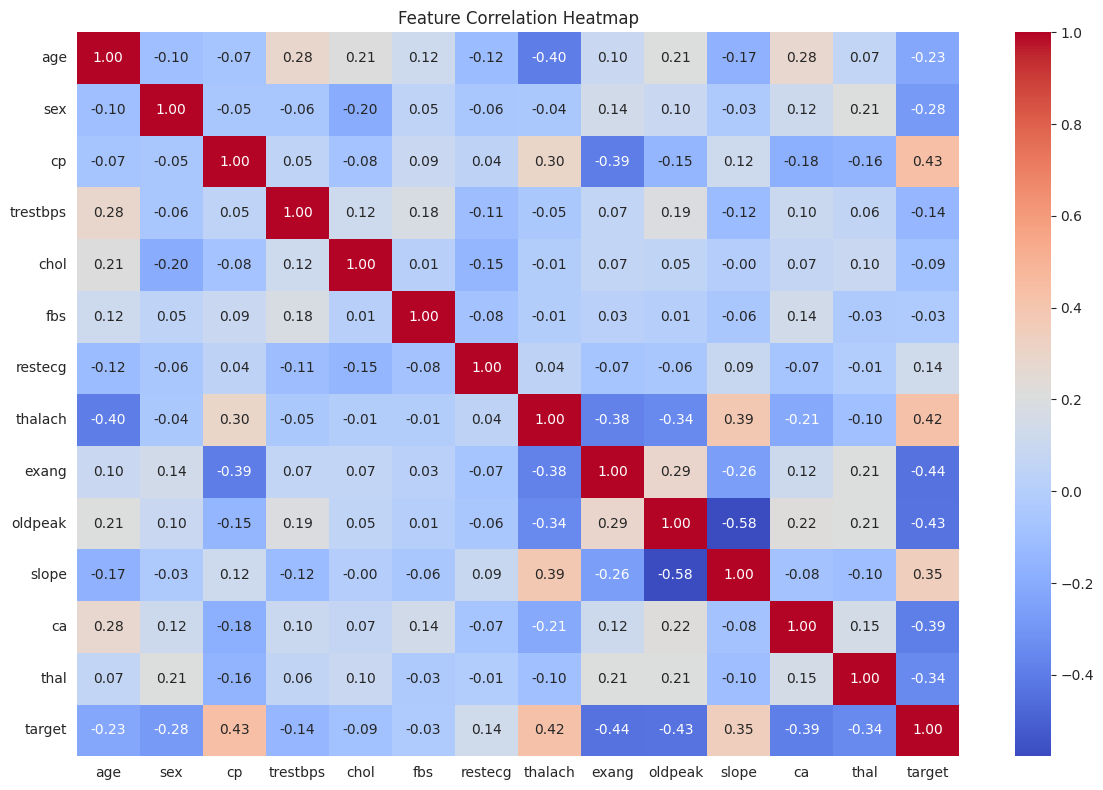

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


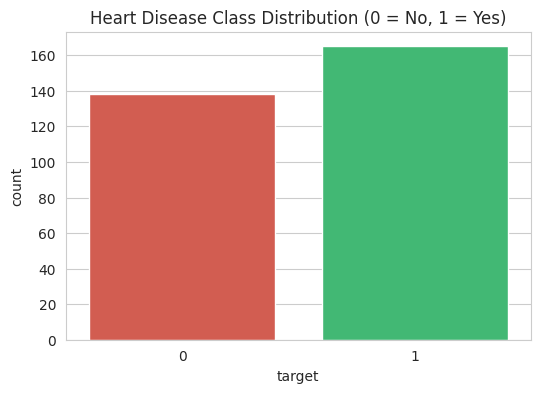

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df, hue="target", palette=["#e74c3c", "#2ecc71"], legend=False)
plt.title("Heart Disease Class Distribution (0 = No, 1 = Yes)")
plt.show()


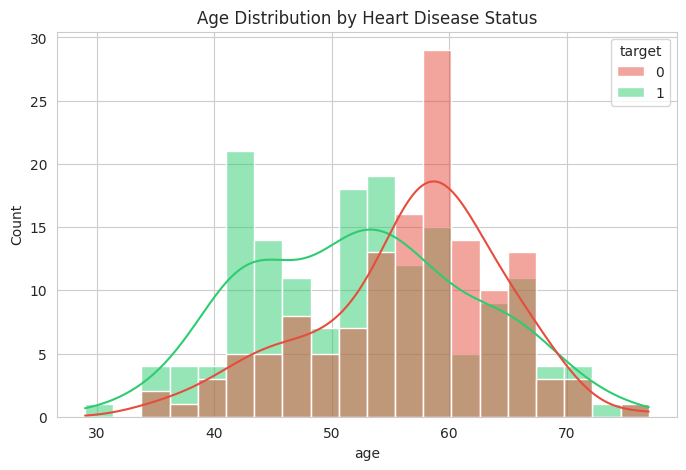

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", hue="target", kde=True, bins=20, palette=["#e74c3c", "#2ecc71"])
plt.title("Age Distribution by Heart Disease Status")
plt.show()


## 4. Preprocessing

Splitting into train/test sets and scaling features (important for Logistic Regression and SVM).


In [9]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train set: (242, 13), Test set: (61, 13)


## 5. Model Training

Training three classifiers to compare: Logistic Regression (baseline), Random Forest, and SVM.


In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "model": model,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

    print(f"--- {name} ---")
    print(f"Accuracy: {results[name]['accuracy']:.4f} | "
          f"Precision: {results[name]['precision']:.4f} | "
          f"Recall: {results[name]['recall']:.4f} | "
          f"F1: {results[name]['f1']:.4f} | "
          f"AUC: {results[name]['auc']:.4f}\n")


--- Logistic Regression ---
Accuracy: 0.8033 | Precision: 0.7692 | Recall: 0.9091 | F1: 0.8333 | AUC: 0.8690



--- Random Forest ---
Accuracy: 0.8197 | Precision: 0.7619 | Recall: 0.9697 | F1: 0.8533 | AUC: 0.9123

--- SVM ---
Accuracy: 0.8197 | Precision: 0.7750 | Recall: 0.9394 | F1: 0.8493 | AUC: 0.8831



## 6. Evaluation

Confusion matrices and ROC curves for each model. In a healthcare context, **recall** matters
a lot — missing a sick patient (false negative) is worse than a false alarm.


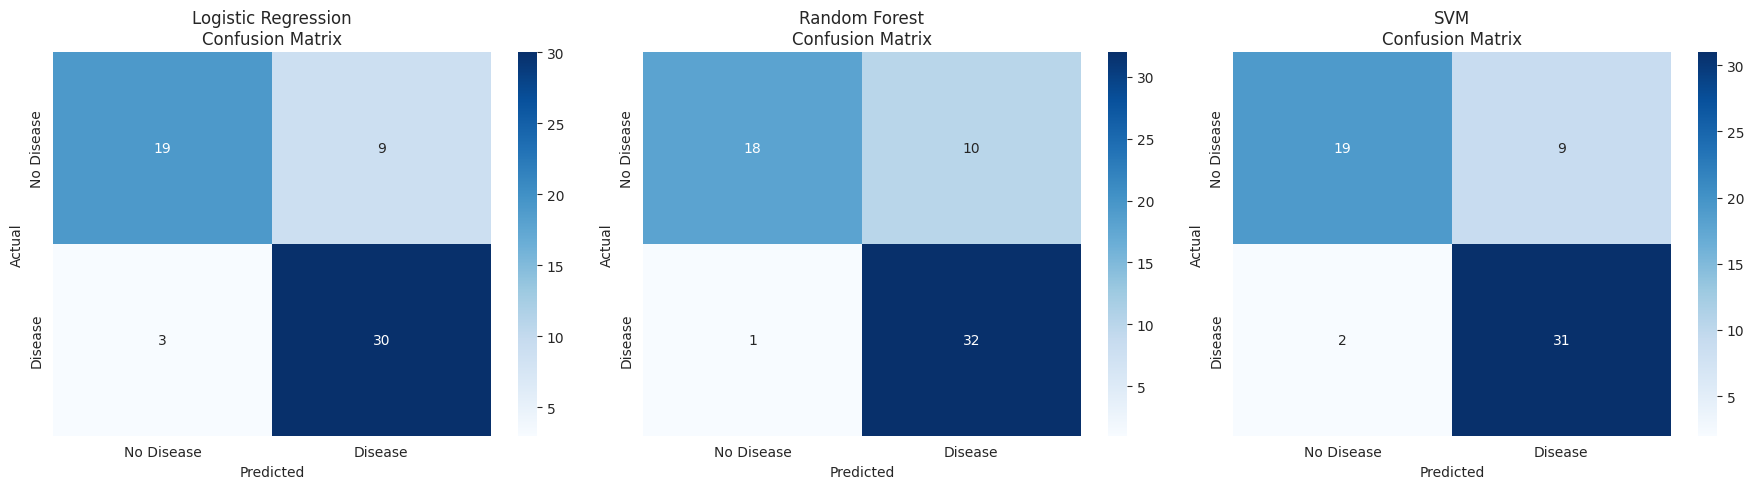

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Disease", "Disease"],
                yticklabels=["No Disease", "Disease"])
    ax.set_title(f"{name}\nConfusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


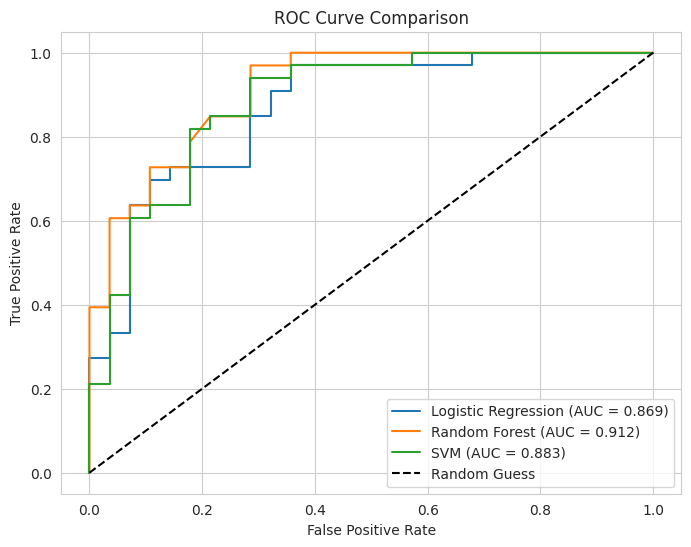

In [12]:
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [13]:
for name, res in results.items():
    print(f"--- {name}: Classification Report ---")
    print(classification_report(y_test, res["y_pred"], target_names=["No Disease", "Disease"]))


--- Logistic Regression: Classification Report ---
              precision    recall  f1-score   support

  No Disease       0.86      0.68      0.76        28
     Disease       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61

--- Random Forest: Classification Report ---
              precision    recall  f1-score   support

  No Disease       0.95      0.64      0.77        28
     Disease       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61

--- SVM: Classification Report ---
              precision    recall  f1-score   support

  No Disease       0.90      0.68      0.78        28
     Disease       0.78      0.94      0.85        33

    accuracy                           0.82        

## 7. Model Comparison & Final Selection

In [14]:
comparison_df = pd.DataFrame({
    name: {
        "Accuracy": res["accuracy"],
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1": res["f1"],
        "ROC AUC": res["auc"],
    }
    for name, res in results.items()
}).T
comparison_df.round(4)


,Accuracy,Precision,Recall,F1,ROC AUC
Logistic Regression,0.8033,0.7692,0.9091,0.8333,0.8690
Random Forest,0.8197,0.7619,0.9697,0.8533,0.9123
SVM,0.8197,0.7750,0.9394,0.8493,0.8831


In [15]:
# Best model chosen by F1 score (balances precision & recall, important in healthcare)
best_model_name = comparison_df["F1"].idxmax()
best_model = results[best_model_name]["model"]
print(f"Best model based on F1 score: {best_model_name}")

joblib.dump(best_model, "best_heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Saved best_heart_disease_model.pkl and scaler.pkl")


Best model based on F1 score: Random Forest
Saved best_heart_disease_model.pkl and scaler.pkl


## 8. Conclusion

All three models performed reasonably well on this dataset (~80-82% accuracy). The chosen
model balances precision and recall via the F1 score, since in a medical diagnosis context
both false positives and false negatives carry real costs — but missing a true case (false
negative) is generally the more dangerous error, so recall was also tracked closely.

**Possible next steps:**
- Hyperparameter tuning (GridSearchCV / RandomizedSearchCV)
- Try gradient boosting models (XGBoost, LightGBM)
- Cross-validation instead of a single train/test split for more robust estimates
- Feature importance analysis to identify the strongest clinical predictors
